# Seaborn Basics — Supply Chain Dataset
Covers all essential seaborn plot types using `aws_supply_chain_orders_raw.csv`.

**Sections:**
1. Setup
2. Distribution Plots — `histplot`, `kdeplot`, `ecdfplot`, `rugplot`
3. Relational Plots — `scatterplot`, `lineplot`, `relplot`
4. Categorical Plots — `countplot`, `barplot`, `boxplot`, `violinplot`, `stripplot`, `swarmplot`, `pointplot`
5. Regression Plots — `regplot`, `lmplot`, `residplot`
6. Matrix Plots — `heatmap`, `clustermap`
7. Multi-grid Plots — `pairplot`, `FacetGrid`, `PairGrid`
8. Themes & Styling

## 1. Setup

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load and lightly prep data
df = pd.read_csv('aws_supply_chain_orders_raw.csv')
df['order_date']    = pd.to_datetime(df['order_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])
df['order_month']   = df['order_date'].dt.month_name()
df = df.dropna(subset=['delivery_time_days', 'region'])  # drop rows with key nulls

print(df.shape)
df.head()

(139, 10)


,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status,order_month
0,ORD-1000,WH-C,West,Router,42,2026-02-16 06:22:56.185879,2026-03-24 06:22:56.186200,4.0,Pending,February
1,ORD-1001,WH-A,West,Laptop,30,2026-02-25 06:22:56.185905,2026-03-15 06:22:56.186205,12.0,Pending,February
2,ORD-1002,WH-C,South,Switch,19,2026-03-13 06:22:56.185910,2026-03-13 06:22:56.186207,13.0,Pending,March
3,ORD-1003,WH-C,North,Server,17,2026-02-14 06:22:56.185913,2026-03-01 06:22:56.186209,9.0,Pending,February
4,ORD-1004,WH-A,East,Laptop,19,2026-02-18 06:22:56.185916,2026-03-11 06:22:56.186211,3.0,Delivered,February


## 2. Distribution Plots
Used to visualize how a single numeric variable is spread.

### 2a. `histplot` — Histogram

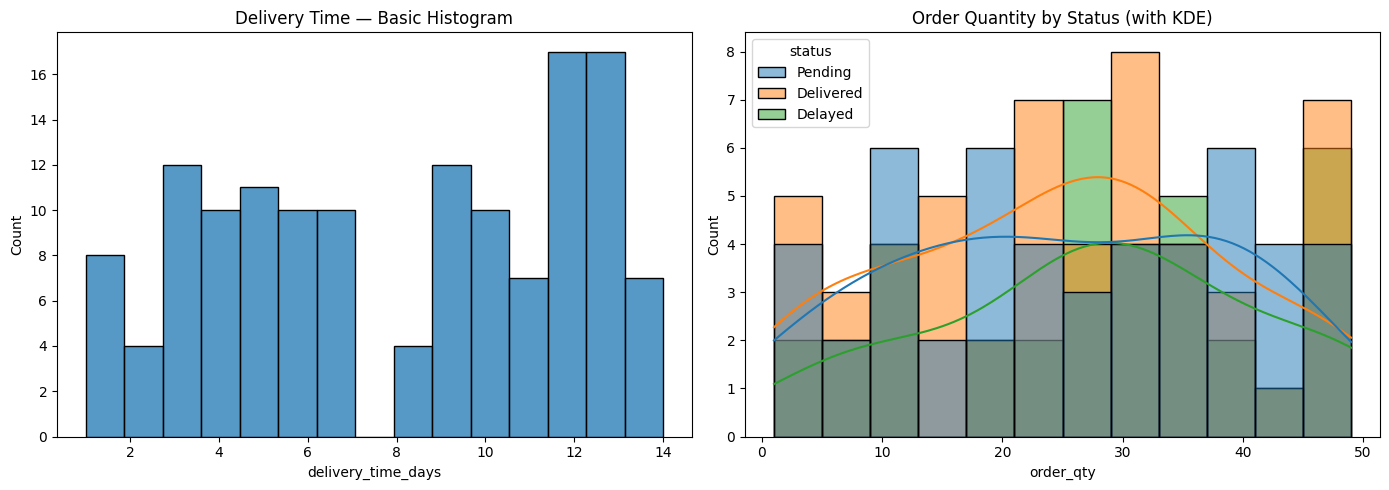

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Basic histogram
sns.histplot(data=df, x='delivery_time_days', bins=15, ax=axes[0])
axes[0].set_title('Delivery Time — Basic Histogram')

# Histogram with KDE overlay and hue
sns.histplot(data=df, x='order_qty', hue='status', kde=True, bins=12, ax=axes[1])
axes[1].set_title('Order Quantity by Status (with KDE)')

plt.tight_layout()
plt.show()

### 2b. `kdeplot` — Kernel Density Estimate

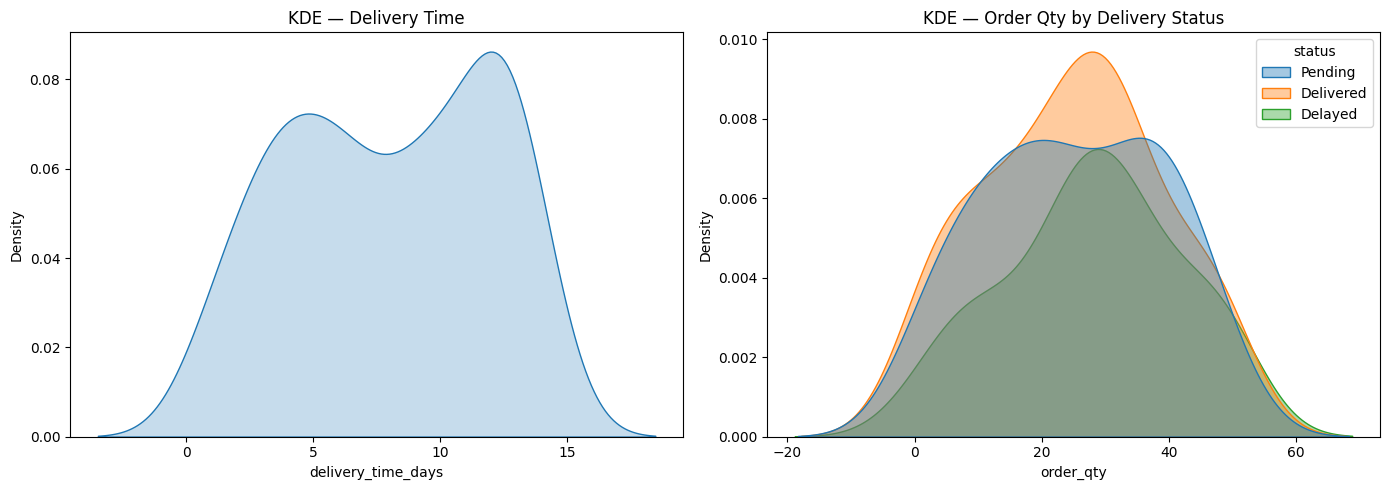

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Univariate KDE
sns.kdeplot(data=df, x='delivery_time_days', fill=True, ax=axes[0])
axes[0].set_title('KDE — Delivery Time')

# KDE split by hue
sns.kdeplot(data=df, x='order_qty', hue='status', fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title('KDE — Order Qty by Delivery Status')

plt.tight_layout()
plt.show()

### 2c. `ecdfplot` — Empirical Cumulative Distribution

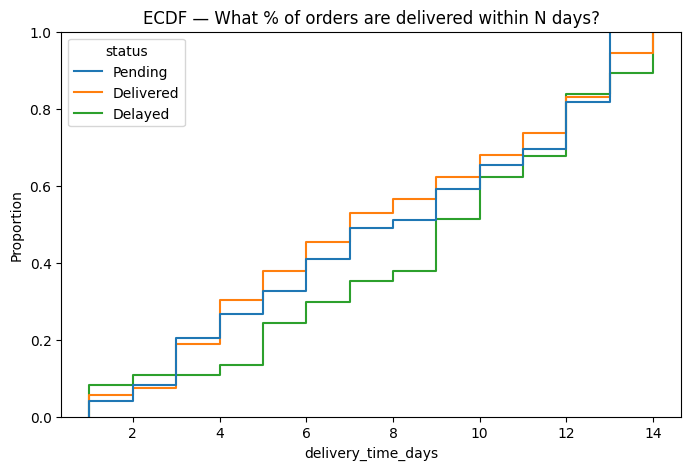

In [4]:
plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x='delivery_time_days', hue='status')
plt.title('ECDF — What % of orders are delivered within N days?')
plt.show()

### 2d. `rugplot` — Tick marks along an axis

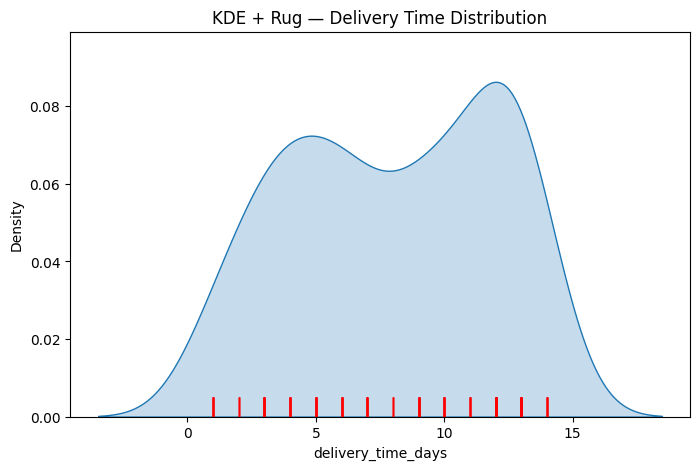

In [5]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='delivery_time_days', fill=True)
sns.rugplot(data=df, x='delivery_time_days', color='red', height=0.05)
plt.title('KDE + Rug — Delivery Time Distribution')
plt.show()

## 3. Relational Plots
Used to show relationships between two numeric variables.

### 3a. `scatterplot`

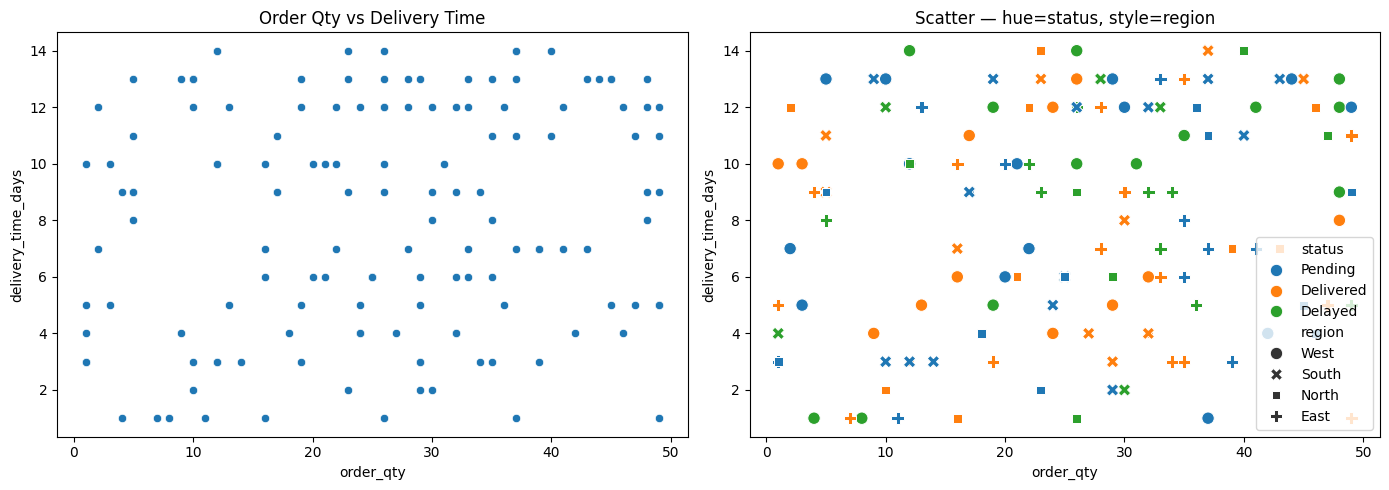

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Basic scatter
sns.scatterplot(data=df, x='order_qty', y='delivery_time_days', ax=axes[0])
axes[0].set_title('Order Qty vs Delivery Time')

# Scatter with hue and style
sns.scatterplot(data=df, x='order_qty', y='delivery_time_days',
                hue='status', style='region', s=80, ax=axes[1])
axes[1].set_title('Scatter — hue=status, style=region')

plt.tight_layout()
plt.show()

### 3b. `lineplot`

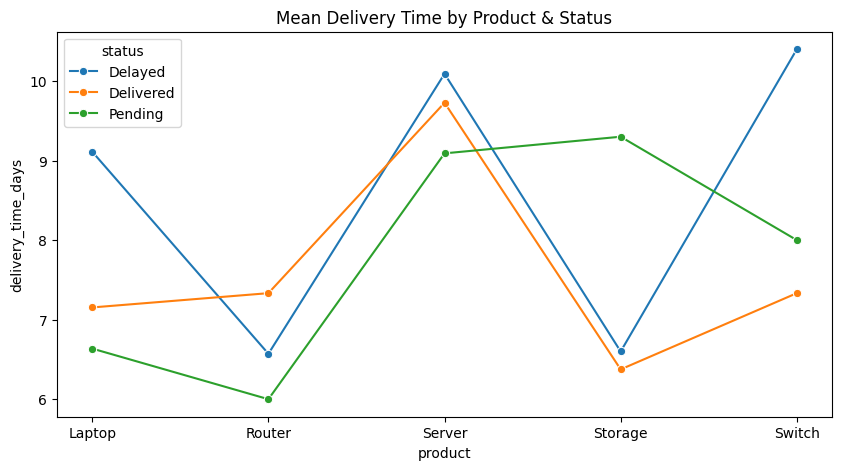

In [7]:
# Aggregate: mean delivery time per product per status
agg = df.groupby(['product', 'status'])['delivery_time_days'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=agg, x='product', y='delivery_time_days', hue='status', marker='o')
plt.title('Mean Delivery Time by Product & Status')
plt.show()

### 3c. `relplot` — Figure-level relational plot (scatter or line)

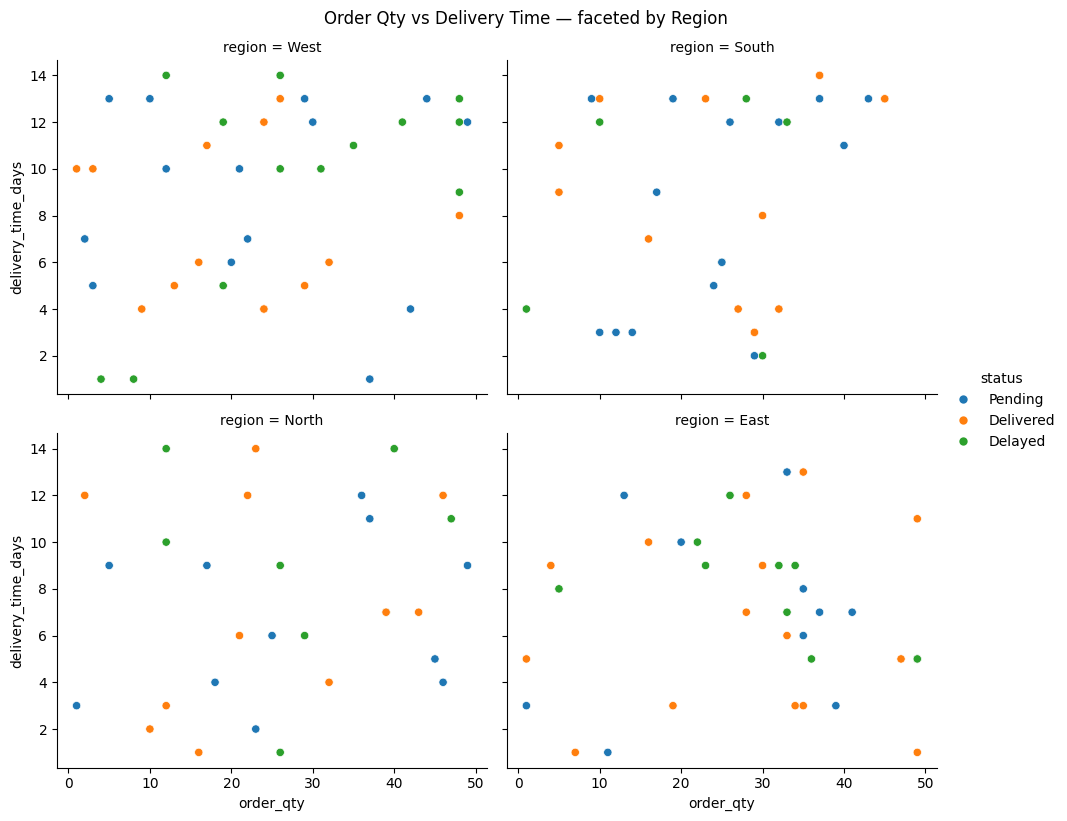

In [8]:
# relplot with col faceting
g = sns.relplot(data=df, x='order_qty', y='delivery_time_days',
                hue='status', col='region', kind='scatter',
                col_wrap=2, height=4, aspect=1.2)
g.figure.suptitle('Order Qty vs Delivery Time — faceted by Region', y=1.02)
plt.show()

## 4. Categorical Plots
Used when one axis is a category.

### 4a. `countplot` — Counts per category

C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\2029217002.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='status', palette='Set2', ax=axes[0])


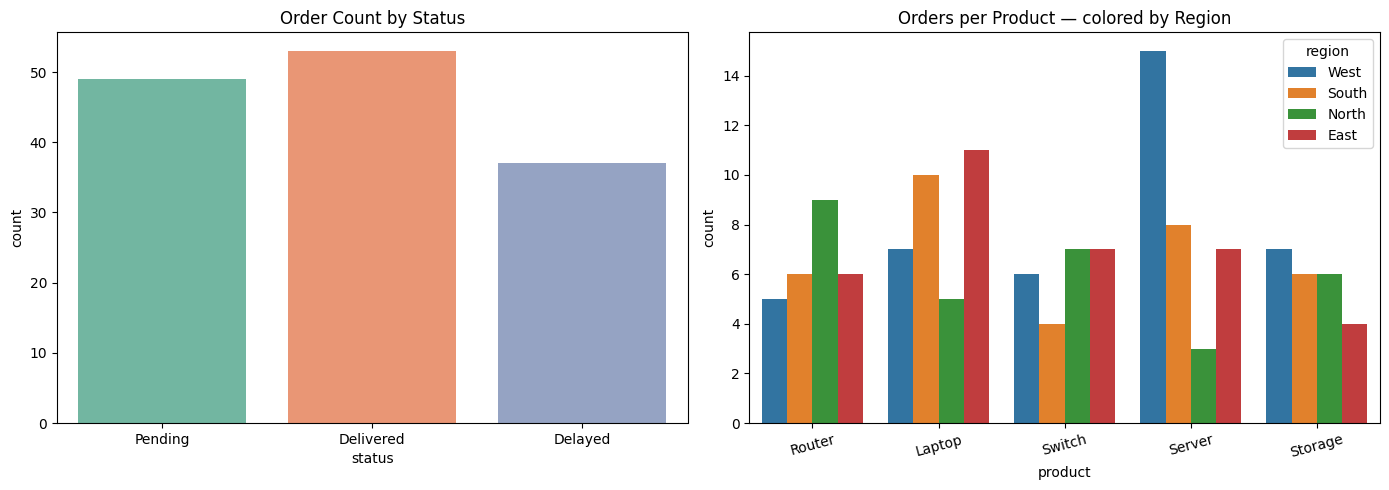

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='status', palette='Set2', ax=axes[0])
axes[0].set_title('Order Count by Status')

sns.countplot(data=df, x='product', hue='region', palette='tab10', ax=axes[1])
axes[1].set_title('Orders per Product — colored by Region')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 4b. `barplot` — Mean (or other stat) per category

C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\1562113520.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='region', y='delivery_time_days', palette='Blues_d', ax=axes[0])


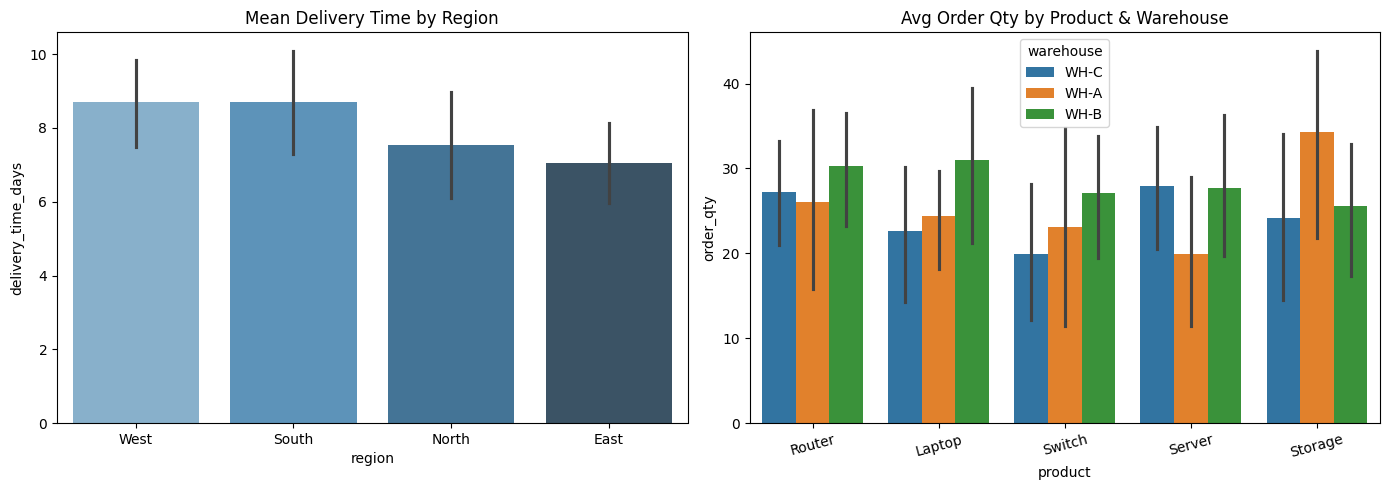

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default: mean with 95% CI error bars
sns.barplot(data=df, x='region', y='delivery_time_days', palette='Blues_d', ax=axes[0])
axes[0].set_title('Mean Delivery Time by Region')

# Grouped barplot with hue
sns.barplot(data=df, x='product', y='order_qty', hue='warehouse', ax=axes[1])
axes[1].set_title('Avg Order Qty by Product & Warehouse')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 4c. `boxplot` — Distribution + outliers per category

C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\468174710.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y='delivery_time_days', palette='Set3', ax=axes[0])


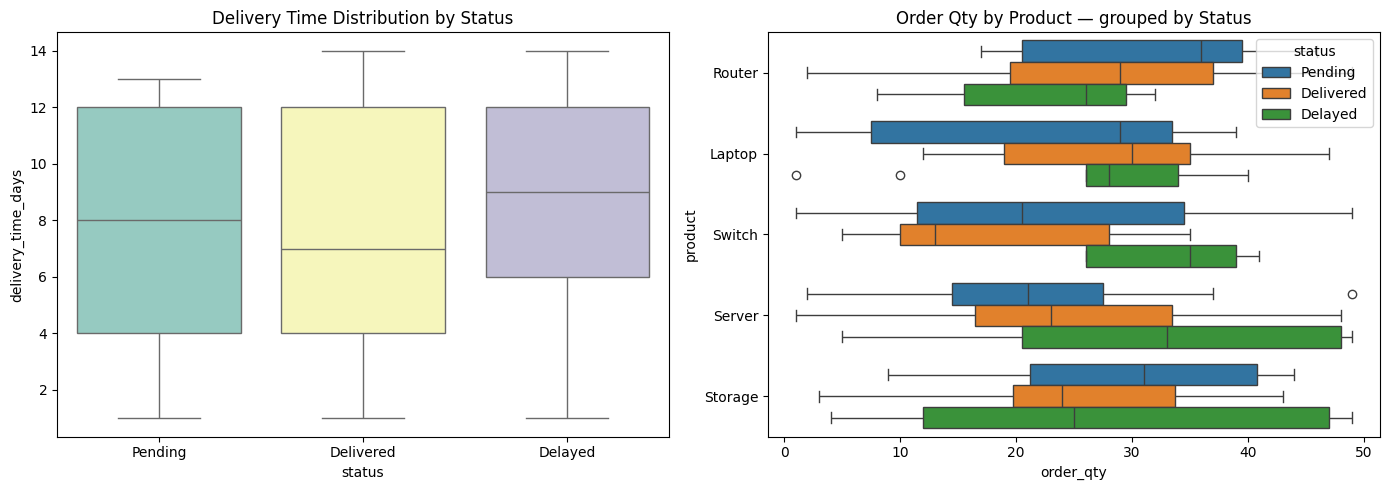

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='status', y='delivery_time_days', palette='Set3', ax=axes[0])
axes[0].set_title('Delivery Time Distribution by Status')

# Horizontal boxplot
sns.boxplot(data=df, y='product', x='order_qty', hue='status', orient='h', ax=axes[1])
axes[1].set_title('Order Qty by Product — grouped by Status')

plt.tight_layout()
plt.show()

### 4d. `violinplot` — KDE shape per category

C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\3348737689.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='region', y='delivery_time_days', palette='muted', ax=axes[0])


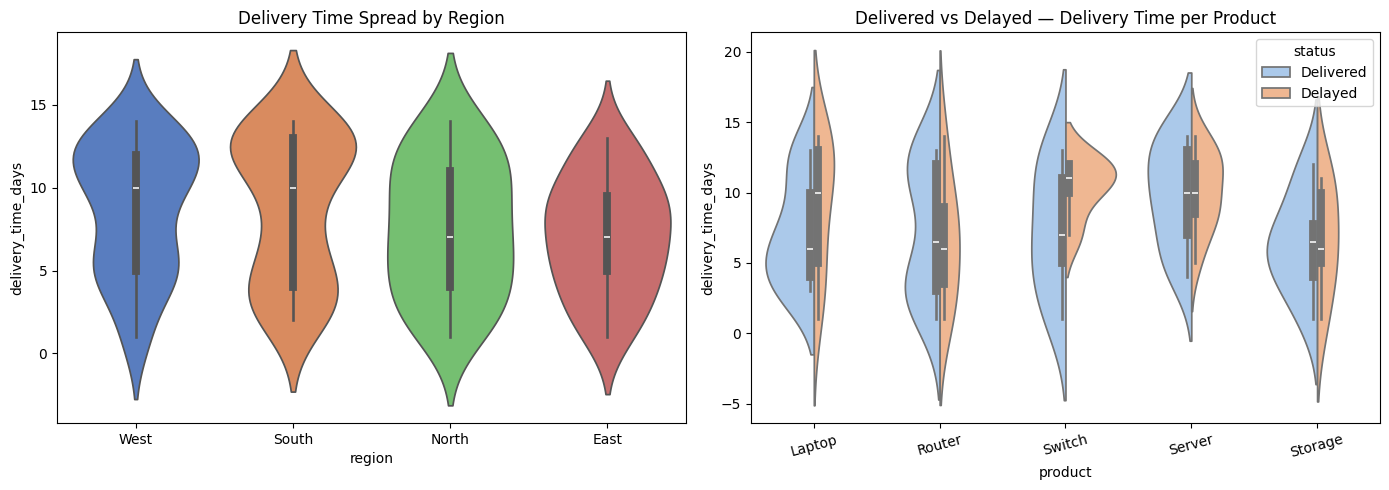

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df, x='region', y='delivery_time_days', palette='muted', ax=axes[0])
axes[0].set_title('Delivery Time Spread by Region')

# Split violin comparing two statuses
df_split = df[df['status'].isin(['Delivered', 'Delayed'])]
sns.violinplot(data=df_split, x='product', y='delivery_time_days',
               hue='status', split=True, palette='pastel', ax=axes[1])
axes[1].set_title('Delivered vs Delayed — Delivery Time per Product')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 4e. `stripplot` — Individual data points per category

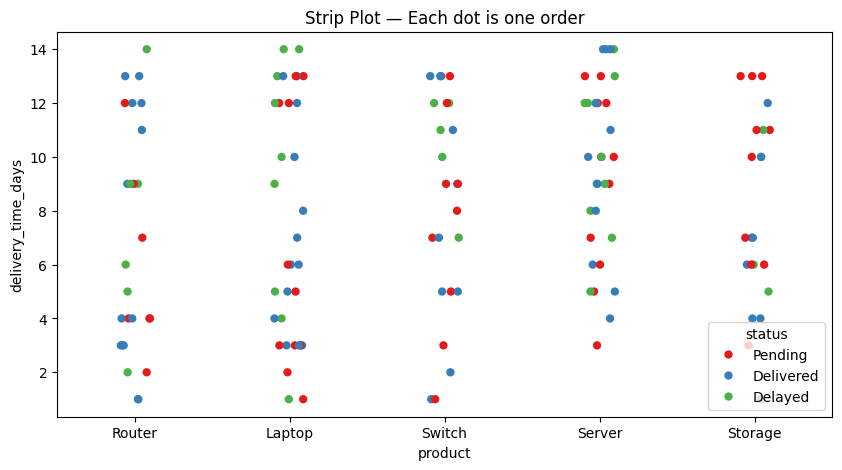

In [13]:
plt.figure(figsize=(10, 5))
sns.stripplot(data=df, x='product', y='delivery_time_days',
              hue='status', jitter=True, size=6, palette='Set1')
plt.title('Strip Plot — Each dot is one order')
plt.show()

### 4f. `swarmplot` — Non-overlapping stripplot

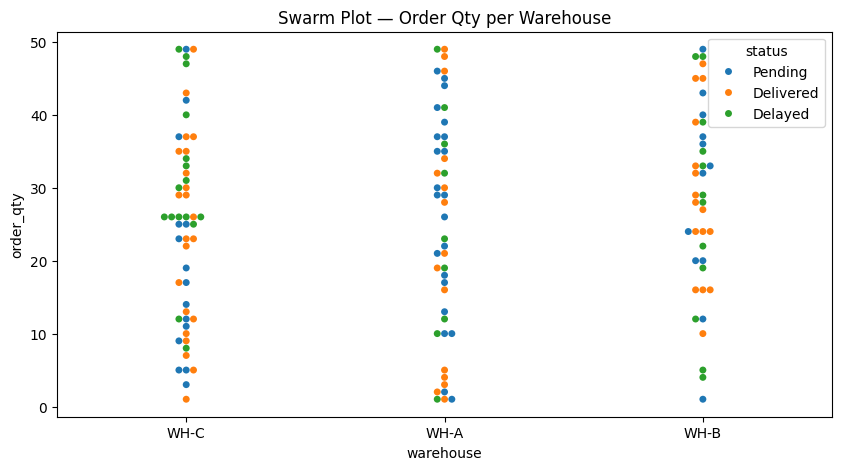

In [14]:
plt.figure(figsize=(10, 5))
sns.swarmplot(data=df, x='warehouse', y='order_qty', hue='status', size=5)
plt.title('Swarm Plot — Order Qty per Warehouse')
plt.show()

### 4g. `boxplot` + `stripplot` overlay (common combo)

C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\2640145767.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='warehouse', y='delivery_time_days',


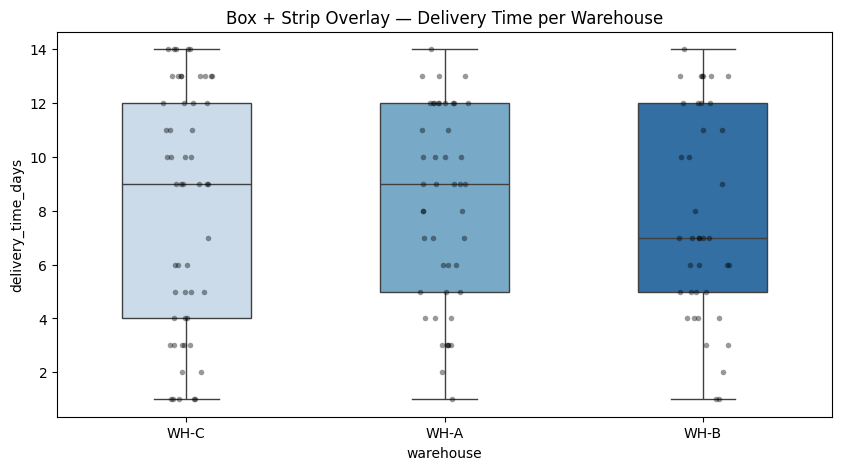

In [15]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='warehouse', y='delivery_time_days',
            palette='Blues', width=0.5, fliersize=0)
sns.stripplot(data=df, x='warehouse', y='delivery_time_days',
              color='black', alpha=0.4, jitter=True, size=4)
plt.title('Box + Strip Overlay — Delivery Time per Warehouse')
plt.show()

### 4h. `pointplot` — Mean + CI connected by lines

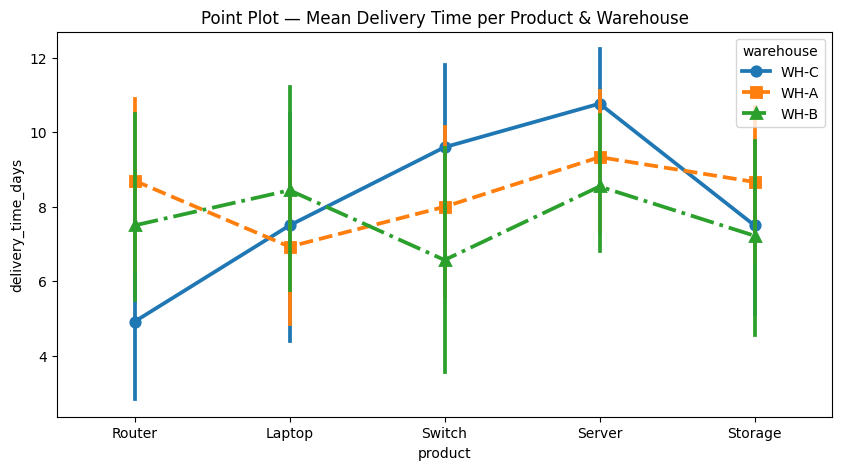

In [16]:
plt.figure(figsize=(10, 5))
sns.pointplot(data=df, x='product', y='delivery_time_days',
              hue='warehouse', markers=['o','s','^'], linestyles=['-','--','-.'])
plt.title('Point Plot — Mean Delivery Time per Product & Warehouse')
plt.show()

### 4i. `catplot` — Figure-level categorical (wraps all cat plot types)

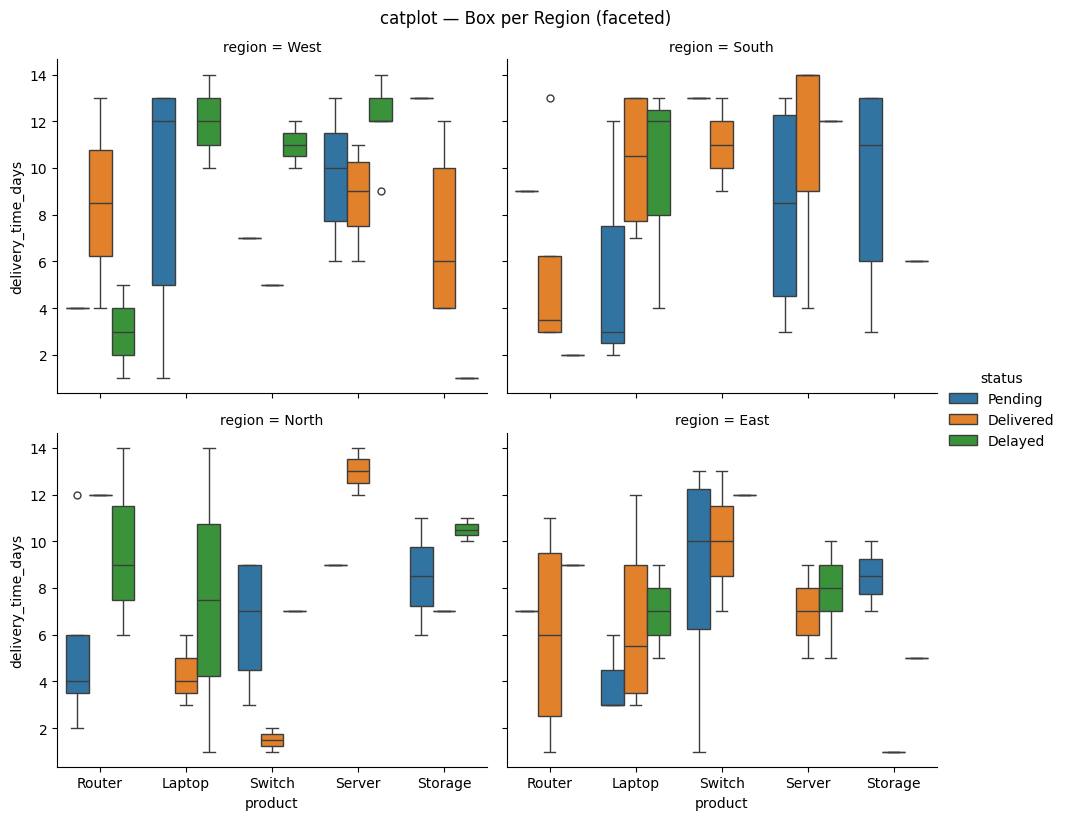

In [17]:
# kind can be: strip, swarm, box, violin, boxen, point, bar, count
g = sns.catplot(data=df, x='product', y='delivery_time_days',
                hue='status', col='region',
                kind='box', col_wrap=2, height=4, aspect=1.2)
g.figure.suptitle('catplot — Box per Region (faceted)', y=1.02)
plt.show()

## 5. Regression Plots
Fit and visualize linear models.

### 5a. `regplot` — Scatter with regression line

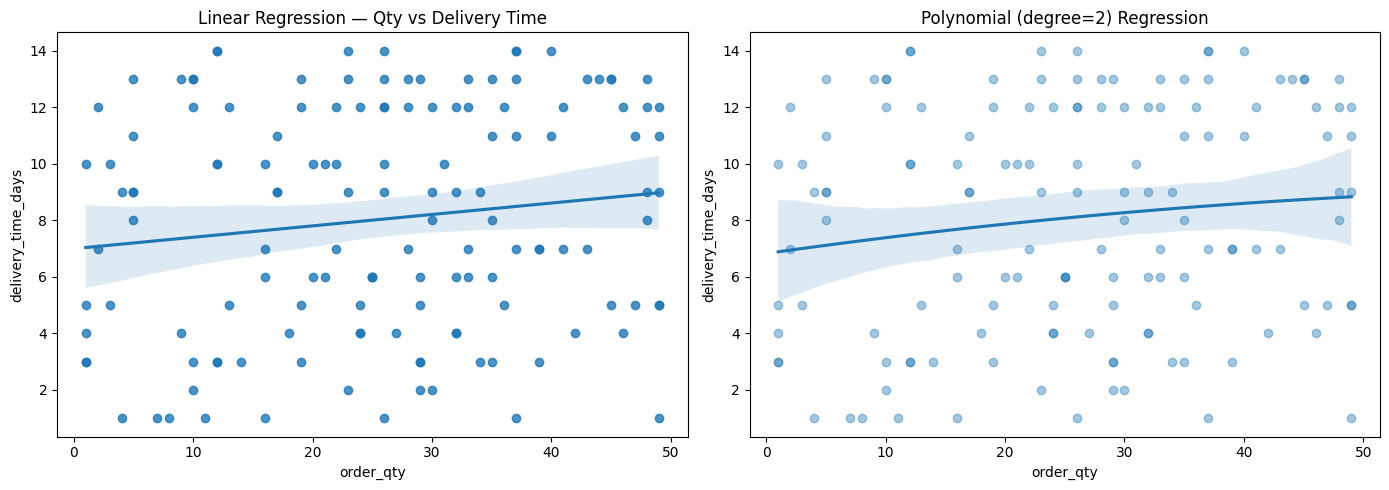

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x='order_qty', y='delivery_time_days', ax=axes[0])
axes[0].set_title('Linear Regression — Qty vs Delivery Time')

# Polynomial fit
sns.regplot(data=df, x='order_qty', y='delivery_time_days',
            order=2, scatter_kws={'alpha': 0.4}, ax=axes[1])
axes[1].set_title('Polynomial (degree=2) Regression')

plt.tight_layout()
plt.show()

### 5b. `lmplot` — Figure-level regplot with faceting

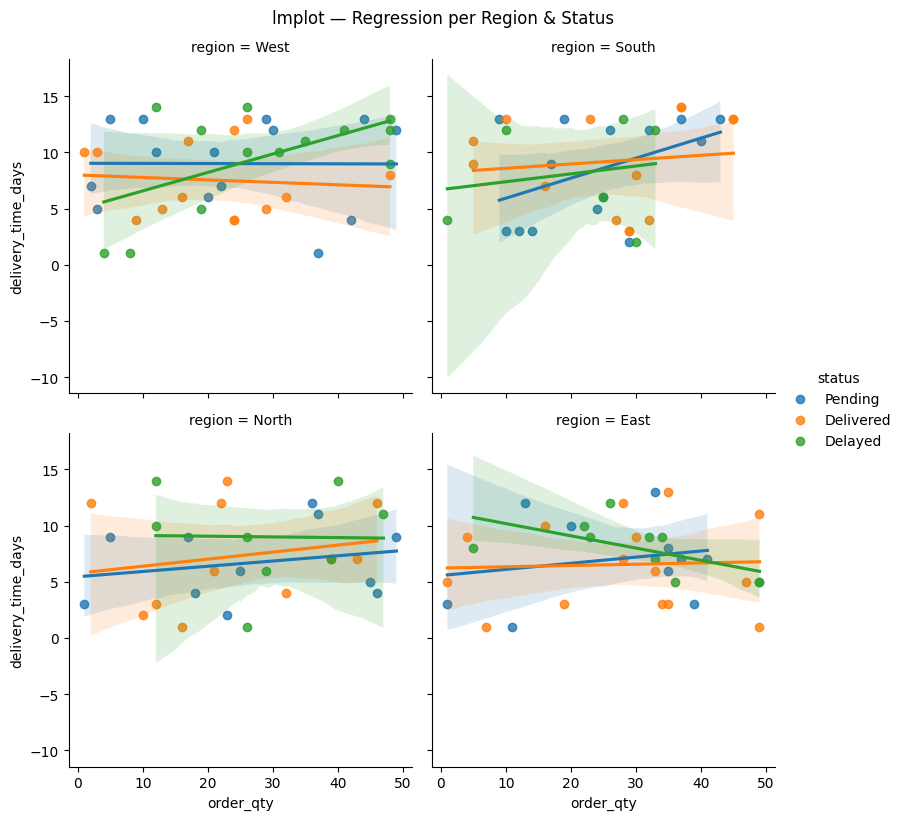

In [19]:
g = sns.lmplot(data=df, x='order_qty', y='delivery_time_days',
               hue='status', col='region', col_wrap=2, height=4)
g.figure.suptitle('lmplot — Regression per Region & Status', y=1.02)
plt.show()

### 5c. `residplot` — Residuals of a linear regression

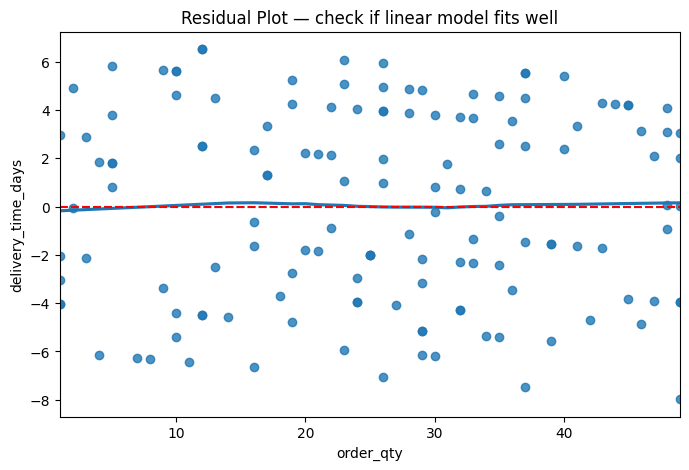

In [20]:
plt.figure(figsize=(8, 5))
sns.residplot(data=df, x='order_qty', y='delivery_time_days', lowess=True)
plt.title('Residual Plot — check if linear model fits well')
plt.axhline(0, color='red', linestyle='--')
plt.show()

## 6. Matrix Plots
Visualize 2D data as color-encoded grids.

### 6a. `heatmap` — Correlation matrix

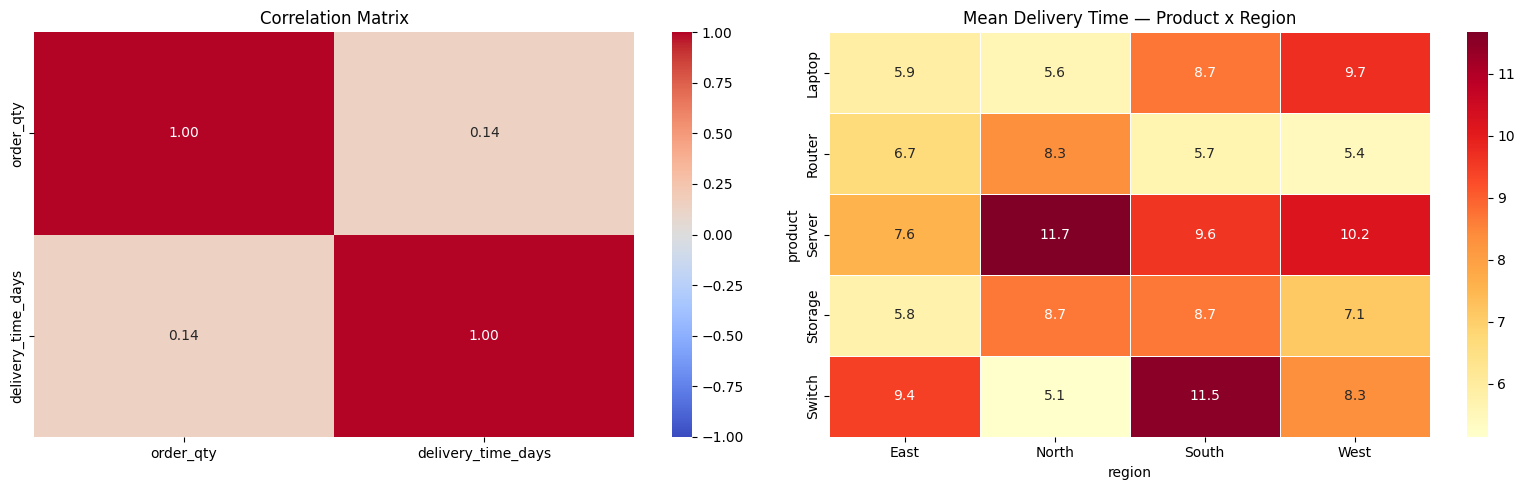

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Correlation heatmap
corr = df[['order_qty', 'delivery_time_days']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation Matrix')

# Pivot table heatmap
pivot = df.pivot_table(values='delivery_time_days',
                       index='product', columns='region', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Mean Delivery Time — Product x Region')

plt.tight_layout()
plt.show()

### 6b. `clustermap` — Heatmap with hierarchical clustering

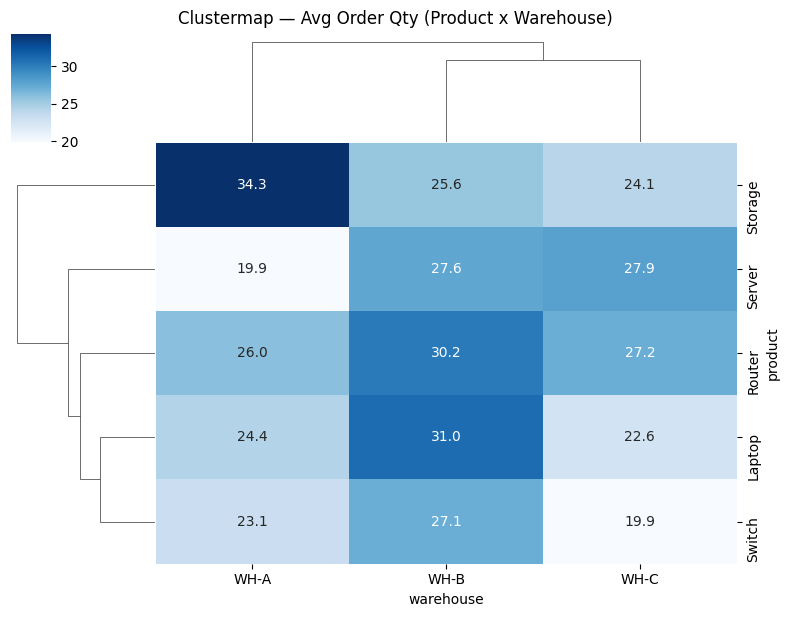

In [22]:
pivot2 = df.pivot_table(values='order_qty',
                        index='product', columns='warehouse', aggfunc='mean').fillna(0)
g = sns.clustermap(pivot2, annot=True, fmt='.1f', cmap='Blues',
                   figsize=(8, 6))
g.figure.suptitle('Clustermap — Avg Order Qty (Product x Warehouse)', y=1.02)
plt.show()

## 7. Multi-grid Plots
Combine multiple subplots in a structured grid.

### 7a. `pairplot` — All pairwise relationships

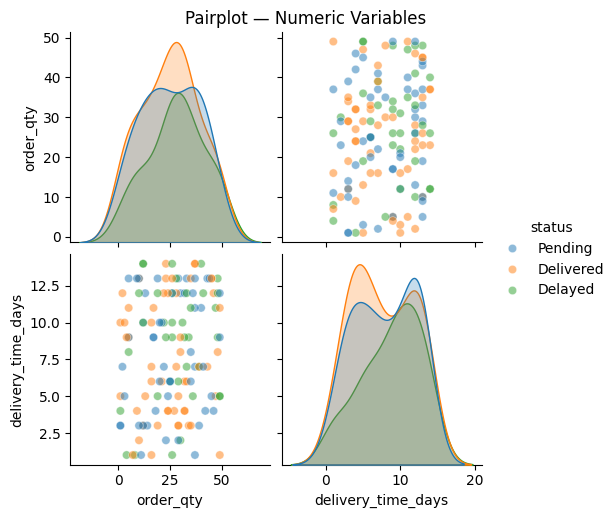

In [23]:
# Only numeric + one categorical hue
g = sns.pairplot(df[['order_qty', 'delivery_time_days', 'status']],
                 hue='status', diag_kind='kde', plot_kws={'alpha': 0.5})
g.figure.suptitle('Pairplot — Numeric Variables', y=1.02)
plt.show()

### 7b. `FacetGrid` — Custom multi-panel plots

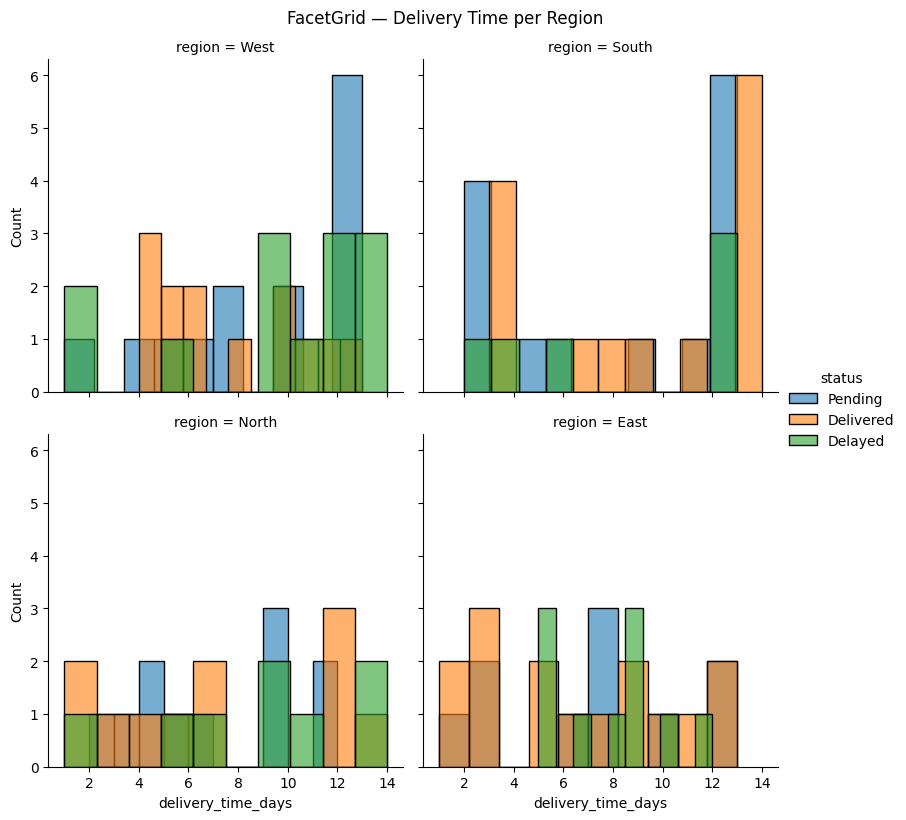

In [24]:
g = sns.FacetGrid(df, col='region', hue='status', col_wrap=2, height=4)
g.map(sns.histplot, 'delivery_time_days', bins=10, alpha=0.6)
g.add_legend()
g.figure.suptitle('FacetGrid — Delivery Time per Region', y=1.02)
plt.show()

### 7c. `PairGrid` — Custom pairwise grid

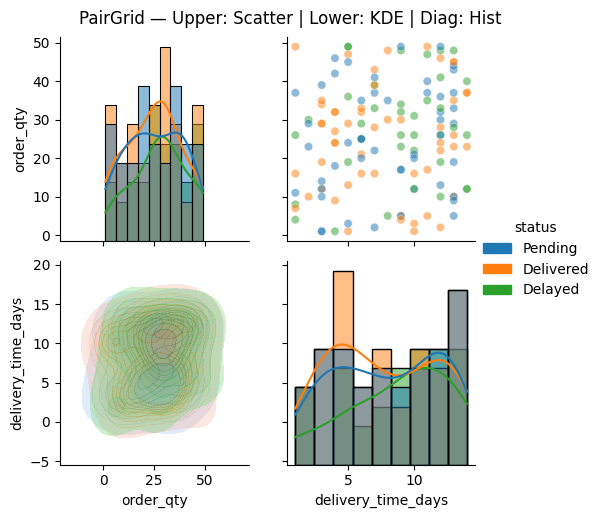

In [25]:
g = sns.PairGrid(df[['order_qty', 'delivery_time_days', 'status']], hue='status')
g.map_upper(sns.scatterplot, alpha=0.5)
g.map_lower(sns.kdeplot, fill=True, alpha=0.3)
g.map_diag(sns.histplot, kde=True)
g.add_legend()
g.figure.suptitle('PairGrid — Upper: Scatter | Lower: KDE | Diag: Hist', y=1.02)
plt.show()

## 8. Themes & Styling
Control the look and feel of all seaborn plots.

C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\3923705273.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='status', y='delivery_time_days',
C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\3923705273.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='status', y='delivery_time_days',
C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\3923705273.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='status', y='delivery_time_days',
C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\3923705273.py:7: Fu

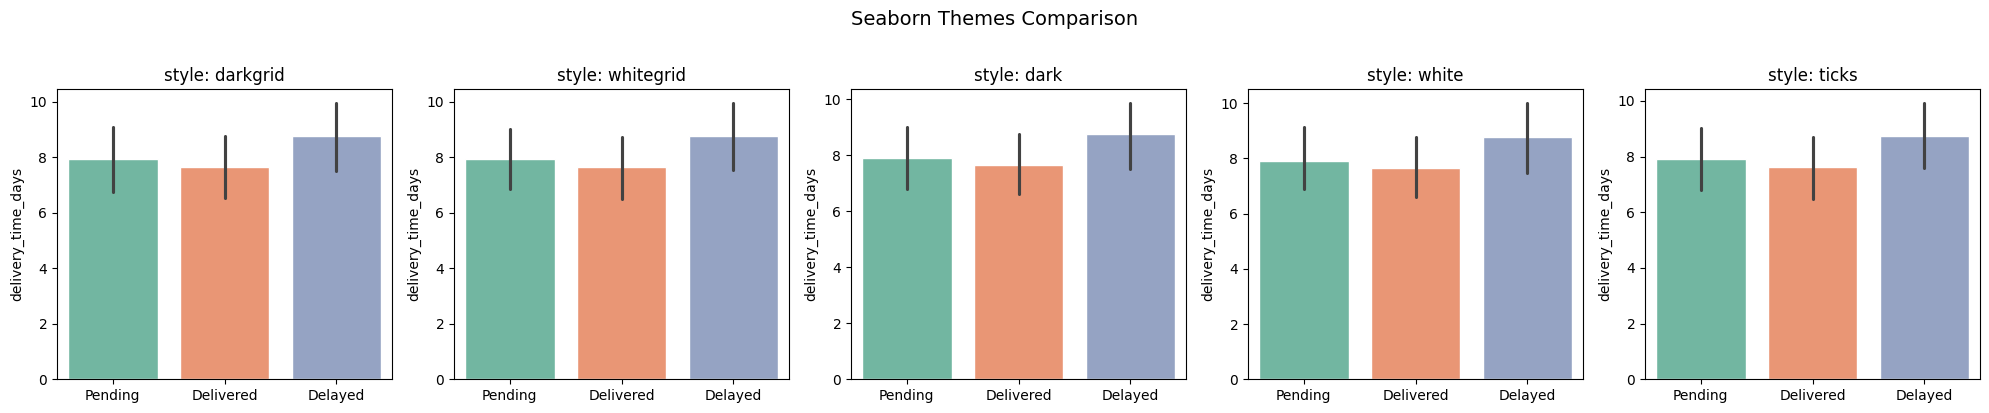

In [26]:
# Available themes: darkgrid, whitegrid, dark, white, ticks
themes = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']

fig, axes = plt.subplots(1, len(themes), figsize=(20, 4))
for ax, theme in zip(axes, themes):
    with sns.axes_style(theme):
        sns.barplot(data=df, x='status', y='delivery_time_days',
                    palette='Set2', ax=ax)
        ax.set_title(f'style: {theme}')
        ax.set_xlabel('')
plt.suptitle('Seaborn Themes Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\858554176.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='order_qty', palette='muted', ax=ax)
C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\858554176.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='order_qty', palette='muted', ax=ax)
C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\858554176.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='order_qty', palette='muted', ax=ax)
C:\Users\Mukund\AppData\Loca

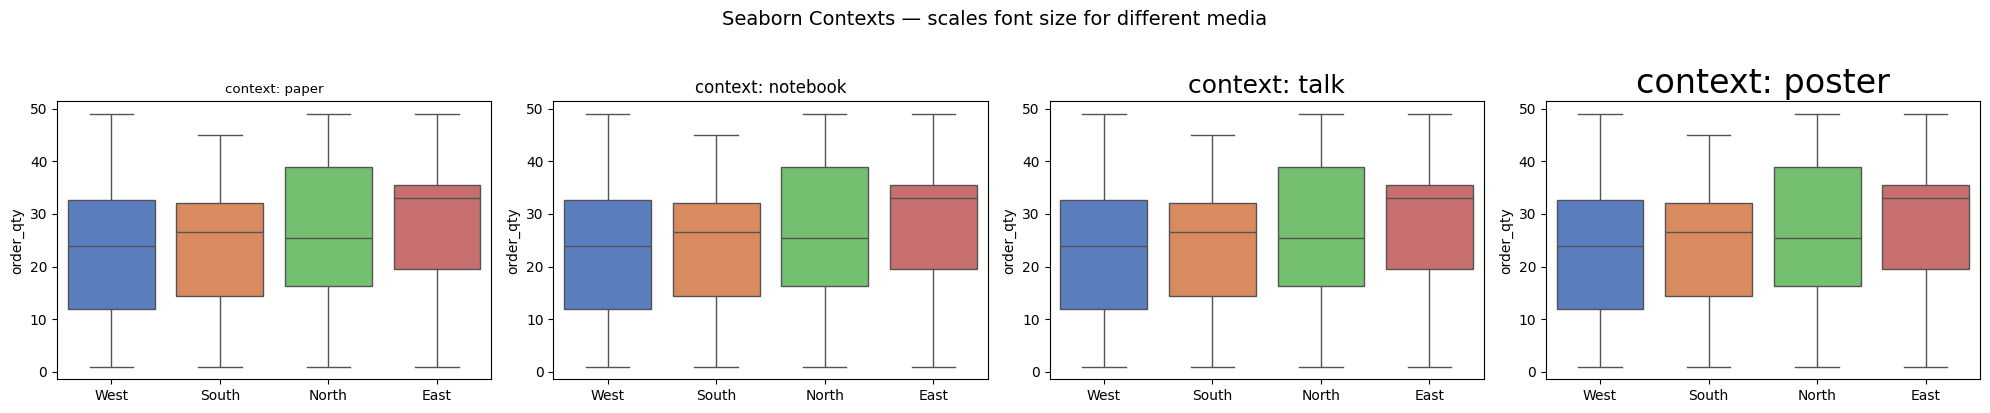

In [27]:
# Context scales: paper, notebook, talk, poster
contexts = ['paper', 'notebook', 'talk', 'poster']

fig, axes = plt.subplots(1, len(contexts), figsize=(20, 4))
for ax, ctx in zip(axes, contexts):
    with sns.plotting_context(ctx):
        sns.boxplot(data=df, x='region', y='order_qty', palette='muted', ax=ax)
        ax.set_title(f'context: {ctx}')
        ax.set_xlabel('')
plt.suptitle('Seaborn Contexts — scales font size for different media', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\3591820118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='product', palette=pal, ax=ax)
C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\3591820118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='product', palette=pal, ax=ax)
C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\3591820118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='product', palette=pal, ax=ax)
C:\Users\Mukund\AppData\Local\Temp\ipykernel_29780\3591820118.py:6: Futur

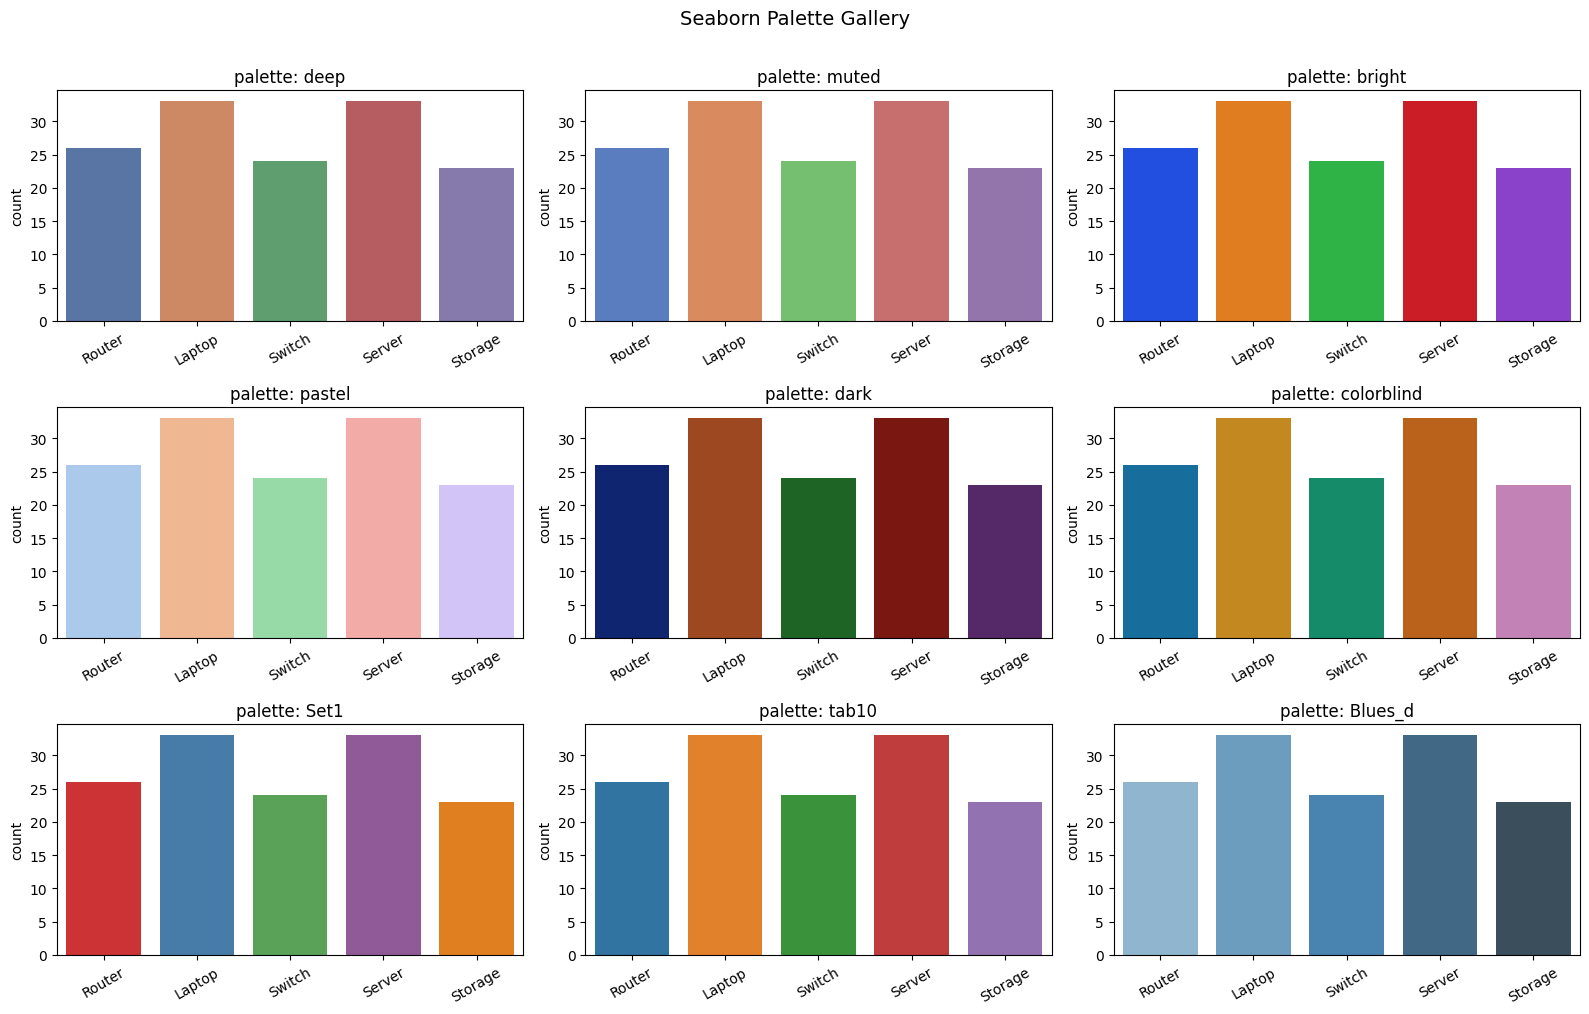

In [28]:
# Built-in color palettes
palettes = ['deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind', 'Set1', 'tab10', 'Blues_d']
fig, axes = plt.subplots(3, 3, figsize=(16, 10))

for ax, pal in zip(axes.flat, palettes):
    sns.countplot(data=df, x='product', palette=pal, ax=ax)
    ax.set_title(f'palette: {pal}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Seaborn Palette Gallery', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Quick Reference Cheatsheet

| Category | Function | Best For |
|---|---|---|
| Distribution | `histplot` | Count / frequency of a numeric var |
| Distribution | `kdeplot` | Smooth density curve |
| Distribution | `ecdfplot` | Cumulative probability |
| Distribution | `rugplot` | Show raw data ticks on axis |
| Relational | `scatterplot` | Two numeric vars, point cloud |
| Relational | `lineplot` | Trend over time or ordered variable |
| Relational | `relplot` | Figure-level scatter/line with facets |
| Categorical | `countplot` | Count rows per category |
| Categorical | `barplot` | Mean (+ CI) per category |
| Categorical | `boxplot` | IQR + median + outliers |
| Categorical | `violinplot` | Full distribution shape per category |
| Categorical | `stripplot` | Individual data points |
| Categorical | `swarmplot` | Non-overlapping individual points |
| Categorical | `pointplot` | Mean + CI connected by lines |
| Categorical | `catplot` | Figure-level wrapper for all cat plots |
| Regression | `regplot` | Scatter + fitted regression line |
| Regression | `lmplot` | Figure-level regplot with facets |
| Regression | `residplot` | Residuals vs fitted |
| Matrix | `heatmap` | 2D grid of values with color |
| Matrix | `clustermap` | Heatmap + hierarchical clustering |
| Multi-grid | `pairplot` | All pairwise variable relationships |
| Multi-grid | `FacetGrid` | Custom faceted subplots |
| Multi-grid | `PairGrid` | Custom pairwise grid |
